In [1]:

from collections import defaultdict, deque
import copy
from typing import Dict, List, Optional

# -----------------------------
# Problem Definition
# -----------------------------

COLORS = ["Red", "Green", "Blue", "Yellow"]

ADJ = {
    "AP": ["TS", "OD", "TN", "KA"],
    "AR": ["AS", "NL"],
    "AS": ["AR", "NL", "ML", "TR", "MZ", "MN", "WB"],
    "BR": ["UP", "JH", "WB"],
    "CG": ["UP", "JH", "OD", "MH"],
    "GA": ["MH", "KA"],
    "GJ": ["MH", "RJ"],
    "HR": ["PB", "HP", "UK", "RJ"],
    "HP": ["JK", "PB", "HR", "UK"],
    "JH": ["BR", "UP", "CG", "OD", "WB"],
    "KA": ["MH", "AP", "TS", "TN", "KL", "GA"],
    "KL": ["KA", "TN"],
    "MP": ["RJ", "UP", "CG", "MH", "GJ"],
    "MH": ["GJ", "MP", "CG", "TS", "KA", "GA"],
    "MN": ["AS", "MZ", "NL"],
    "ML": ["AS", "TR"],
    "MZ": ["AS", "MN", "TR"],
    "NL": ["AR", "AS", "MN"],
    "OD": ["WB", "JH", "CG", "AP", "TS"],
    "PB": ["JK", "HP", "HR", "RJ"],
    "RJ": ["PB", "HR", "MP", "GJ", "UP"],
    "SK": ["WB"],
    "TN": ["AP", "KA", "KL"],
    "TS": ["MH", "KA", "AP", "OD"],
    "TR": ["AS", "ML", "MZ"],
    "UP": ["UK", "HR", "RJ", "MP", "CG", "JH", "BR"],
    "UK": ["HP", "HR", "UP"],
    "WB": ["BR", "JH", "OD", "AS", "SK"],
    "JK": ["HP", "PB"]
}

VARIABLES = sorted(list(ADJ.keys()))

class CSP:
    def __init__(self, variables: List[str], domains: Dict[str, List[str]], neighbors: Dict[str, List[str]]):
        self.variables = variables
        self.domains = {v: list(domains[v]) for v in variables}
        self.neighbors = {v: list(neighbors[v]) for v in variables}

    def constraint(self, var: str, value: str, assignment: Dict[str, str]) -> bool:
        for n in self.neighbors[var]:
            if n in assignment and assignment[n] == value:
                return False
        return True

def is_complete(assignment: Dict[str, str], variables: List[str]) -> bool:
    return len(assignment) == len(variables)

def consistent(csp: CSP, var: str, value: str, assignment: Dict[str, str]) -> bool:
    return csp.constraint(var, value, assignment)

def select_unassigned_variable_plain(assignment: Dict[str, str], variables: List[str]) -> str:
    for v in variables:
        if v not in assignment:
            return v
    raise ValueError("No unassigned variables left.")

def order_domain_values_plain(var: str, domains: Dict[str, List[str]]) -> List[str]:
    return list(domains[var])

def select_unassigned_variable_mrv(csp: CSP, assignment: Dict[str, str], domains: Dict[str, List[str]]) -> str:
    best_vars = []
    best_count = None
    for v in csp.variables:
        if v in assignment:
            continue
        legal = [val for val in domains[v] if consistent(csp, v, val, assignment)]
        count = len(legal)
        if best_count is None or count < best_count:
            best_count = count
            best_vars = [v]
        elif count == best_count:
            best_vars.append(v)
    if len(best_vars) == 1:
        return best_vars[0]
    def unassigned_degree(v):
        return sum(1 for n in csp.neighbors[v] if n not in assignment)
    return max(best_vars, key=unassigned_degree)

def order_domain_values_lcv(csp: CSP, var: str, domains: Dict[str, List[str]], assignment: Dict[str, str]) -> List[str]:
    def conflicts(value: str) -> int:
        conflicts_count = 0
        for n in csp.neighbors[var]:
            if n in assignment:
                continue
            for nval in domains[n]:
                if nval == value:
                    conflicts_count += 1
        return conflicts_count
    values = list(domains[var])
    values.sort(key=lambda val: conflicts(val))
    return values

def ac3(csp: CSP, domains: Dict[str, List[str]]) -> bool:
    from collections import deque
    queue = deque()
    for Xi in csp.variables:
        for Xj in csp.neighbors[Xi]:
            queue.append((Xi, Xj))
    while queue:
        Xi, Xj = queue.popleft()
        if revise(csp, domains, Xi, Xj):
            if not domains[Xi]:
                return False
            for Xk in csp.neighbors[Xi]:
                if Xk != Xj:
                    queue.append((Xk, Xi))
    return True

def revise(csp: CSP, domains: Dict[str, List[str]], Xi: str, Xj: str) -> bool:
    removed = False
    to_remove = []
    for x in domains[Xi]:
        if all(x == y for y in domains[Xj]):
            to_remove.append(x)
    if to_remove:
        for x in to_remove:
            domains[Xi].remove(x)
        removed = True
    return removed

class SearchResult:
    def __init__(self, assignment: Dict[str, str], steps: int, mrv_trace=None, lcv_trace=None):
        self.assignment = assignment
        self.steps = steps
        self.mrv_trace = mrv_trace or []
        self.lcv_trace = lcv_trace or []

def backtracking_plain(csp: CSP) -> SearchResult:
    steps = 0
    def backtrack(assignment: Dict[str, str]) -> Optional[Dict[str, str]]:
        nonlocal steps
        if is_complete(assignment, csp.variables):
            return assignment
        var = select_unassigned_variable_plain(assignment, csp.variables)
        for value in order_domain_values_plain(var, csp.domains):
            steps += 1
            if consistent(csp, var, value, assignment):
                assignment[var] = value
                result = backtrack(assignment)
                if result is not None:
                    return result
                del assignment[var]
        return None
    solution = backtrack({})
    return SearchResult(solution or {}, steps)

def backtracking_mrv_lcv(csp: CSP, verbose_trace: bool = True) -> SearchResult:
    steps = 0
    mrv_trace = []
    lcv_trace = []
    def backtrack(assignment: Dict[str, str], domains: Dict[str, List[str]]) -> Optional[Dict[str, str]]:
        nonlocal steps
        if is_complete(assignment, csp.variables):
            return assignment
        var = select_unassigned_variable_mrv(csp, assignment, domains)
        if verbose_trace:
            mrv_trace.append(var)
        values = order_domain_values_lcv(csp, var, domains, assignment)
        if verbose_trace:
            lcv_trace.append(values[:])
        for value in values:
            steps += 1
            if consistent(csp, var, value, assignment):
                assignment[var] = value
                new_domains = copy.deepcopy(domains)
                for n in csp.neighbors[var]:
                    if n not in assignment and value in new_domains[n]:
                        new_domains[n] = [v for v in new_domains[n] if v != value]
                        if not new_domains[n]:
                            break
                else:
                    result = backtrack(assignment, new_domains)
                    if result is not None:
                        return result
                del assignment[var]
        return None
    init_domains = {v: list(COLORS) for v in csp.variables}
    solution = backtrack({}, init_domains)
    return SearchResult(solution or {}, steps, mrv_trace, lcv_trace)

def backtracking_mrv_lcv_ac3(csp: CSP, verbose_trace: bool = True) -> SearchResult:
    steps = 0
    mrv_trace = []
    lcv_trace = []
    def backtrack(assignment: Dict[str, str], domains: Dict[str, List[str]]) -> Optional[Dict[str, str]]:
        nonlocal steps
        if is_complete(assignment, csp.variables):
            return assignment
        var = select_unassigned_variable_mrv(csp, assignment, domains)
        if verbose_trace:
            mrv_trace.append(var)
        values = order_domain_values_lcv(csp, var, domains, assignment)
        if verbose_trace:
            lcv_trace.append(values[:])
        for value in values:
            steps += 1
            if consistent(csp, var, value, assignment):
                assignment[var] = value
                new_domains = copy.deepcopy(domains)
                new_domains[var] = [value]
                if ac3(csp, new_domains):
                    if all(len(new_domains[v]) > 0 for v in csp.variables):
                        result = backtrack(assignment, new_domains)
                        if result is not None:
                            return result
                del assignment[var]
        return None
    init_domains = {v: list(COLORS) for v in csp.variables}
    pre_domains = copy.deepcopy(init_domains)
    ac3(csp, pre_domains)
    solution = backtrack({}, pre_domains)
    return SearchResult(solution or {}, steps, mrv_trace, lcv_trace)

def run_all():
    domains_all = {v: list(COLORS) for v in VARIABLES}
    csp = CSP(VARIABLES, domains_all, ADJ)
    plain_res = backtracking_plain(csp)
    mrv_lcv_res = backtracking_mrv_lcv(csp, verbose_trace=True)
    mrv_lcv_ac3_res = backtracking_mrv_lcv_ac3(csp, verbose_trace=True)

    print("== Solutions ==")
    print("Plain:", plain_res.assignment)
    print("MRV+LCV:", mrv_lcv_res.assignment)
    print("MRV+LCV+AC-3:", mrv_lcv_ac3_res.assignment)
    print()
    print("== Steps Explored ==")
    print("Plain Backtracking:", plain_res.steps)
    print("Backtracking + MRV+LCV:", mrv_lcv_res.steps)
    print("Backtracking + MRV+LCV+AC-3:", mrv_lcv_ac3_res.steps)
    print()
    print("== MRV Trace (variable order) ==")
    print("MRV+LCV:", mrv_lcv_res.mrv_trace)
    print("MRV+LCV+AC-3:", mrv_lcv_ac3_res.mrv_trace)
    print()
    print("== LCV Orders per step ==")
    print("MRV+LCV:")
    for i, order in enumerate(mrv_lcv_res.lcv_trace, 1):
        print(f"  Step {i}: {order}")
    print("MRV+LCV+AC-3:")
    for i, order in enumerate(mrv_lcv_ac3_res.lcv_trace, 1):
        print(f"  Step {i}: {order}")

if __name__ == "__main__":
    run_all()


== Solutions ==
Plain: {'AP': 'Red', 'AR': 'Red', 'AS': 'Green', 'BR': 'Red', 'CG': 'Red', 'GA': 'Red', 'GJ': 'Red', 'HP': 'Red', 'HR': 'Green', 'JH': 'Green', 'JK': 'Green', 'KA': 'Green', 'KL': 'Red', 'MH': 'Blue', 'ML': 'Red', 'MN': 'Red', 'MP': 'Green', 'MZ': 'Blue', 'NL': 'Blue', 'OD': 'Blue', 'PB': 'Blue', 'RJ': 'Yellow', 'SK': 'Red', 'TN': 'Blue', 'TR': 'Yellow', 'TS': 'Yellow', 'UK': 'Yellow', 'UP': 'Blue', 'WB': 'Yellow'}
MRV+LCV: {'AS': 'Red', 'WB': 'Green', 'JH': 'Red', 'OD': 'Blue', 'CG': 'Green', 'UP': 'Blue', 'BR': 'Yellow', 'MP': 'Red', 'MH': 'Blue', 'RJ': 'Green', 'GJ': 'Yellow', 'HR': 'Red', 'PB': 'Blue', 'HP': 'Green', 'UK': 'Yellow', 'JK': 'Red', 'KA': 'Red', 'AP': 'Green', 'TS': 'Yellow', 'TN': 'Blue', 'GA': 'Green', 'KL': 'Green', 'MN': 'Green', 'MZ': 'Blue', 'NL': 'Blue', 'TR': 'Green', 'AR': 'Green', 'ML': 'Blue', 'SK': 'Red'}
MRV+LCV+AC-3: {'AS': 'Red', 'WB': 'Green', 'JH': 'Red', 'OD': 'Blue', 'CG': 'Green', 'UP': 'Blue', 'BR': 'Yellow', 'MP': 'Red', 'MH': 'Blu

Plain Backtracking Solution: {'V': 'Red', 'SA': 'Green', 'NT': 'Blue', 'WA': 'Red', 'NSW': 'Blue', 'Q': 'Red', 'T': 'Red'}
Plain Backtracking Steps: 11


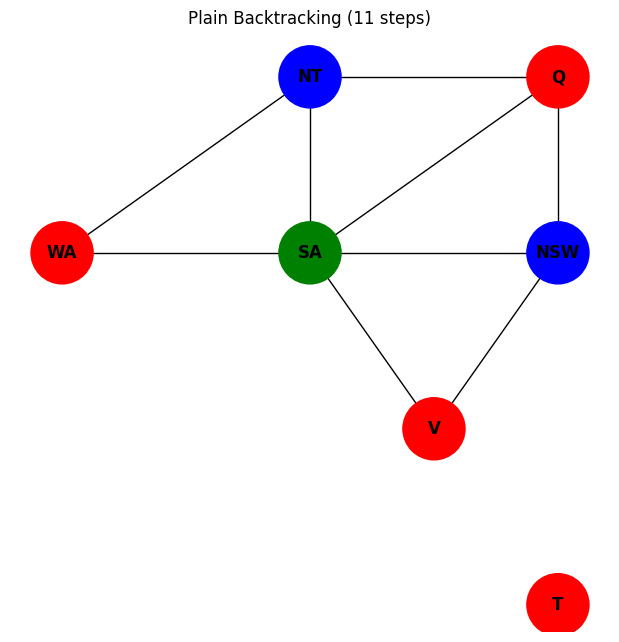

In [2]:
# Map Coloring Problem using Backtracking
# Demo for Part A: Plain Backtracking vs Backtracking with MRV + LCV + Visualization

import matplotlib.pyplot as plt
import networkx as nx

variables = ["V", "SA", "NT", "WA", "NSW", "Q", "T"]
colors = ["Red", "Green", "Blue"]

# Adjacency list (neighbors)
neighbors = {
    "WA": ["NT", "SA"],
    "NT": ["WA", "SA", "Q"],
    "SA": ["WA", "NT", "Q", "NSW", "V"],
    "Q": ["NT", "SA", "NSW"],
    "NSW": ["SA", "Q", "V"],
    "V": ["SA", "NSW"],
    "T": []
}

# ---------------- Utility Functions ------------------

# Check if assignment is valid
def is_valid(assignment, var, value):
    for n in neighbors[var]:
        if n in assignment and assignment[n] == value:
            return False
    return True

# ---------------- Plain Backtracking ------------------

plain_steps = 0
def backtrack_plain(assignment):
    global plain_steps
    plain_steps += 1

    if len(assignment) == len(variables):
        return assignment

    # Pick first unassigned variable (no heuristic)
    for var in variables:
        if var not in assignment:
            break

    for value in colors:  # try values in fixed order
        if is_valid(assignment, var, value):
            assignment[var] = value
            result = backtrack_plain(assignment)
            if result:
                return result
            del assignment[var] # backtrack

    return None

# ---------------- Visualization ------------------

def visualize_coloring(solution, title):
    G = nx.Graph()

    # Add nodes and edges
    for var in variables:
        G.add_node(var)
    for var, neighs in neighbors.items():
        for n in neighs:
            G.add_edge(var, n)

    # Node positions for Australia-like layout
    pos = {
        "WA": (0, 0),
        "NT": (2, 2),
        "SA": (2, 0),
        "Q": (4, 2),
        "NSW": (4, 0),
        "V": (3, -2),
        "T": (4, -4)
    }

    node_colors = [solution.get(node, "white") for node in G.nodes()]

    plt.figure(figsize=(6, 6))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=2000,
        font_size=12,
        font_weight="bold",
        edge_color="black"
    )
    plt.title(title)
    plt.show()

# ---------------- Run Demo ------------------

if __name__ == "__main__":
    # Plain Backtracking
    plain_solution = backtrack_plain({})
    print("Plain Backtracking Solution:", plain_solution)
    print("Plain Backtracking Steps:", plain_steps)
    visualize_coloring(plain_solution, f"Plain Backtracking ({plain_steps} steps)")


Backtracking with MRV + LCV Solution: {'V': 'Red', 'SA': 'Green', 'NSW': 'Blue', 'Q': 'Red', 'NT': 'Blue', 'WA': 'Red', 'T': 'Red'}
Backtracking with MRV + LCV Steps: 8


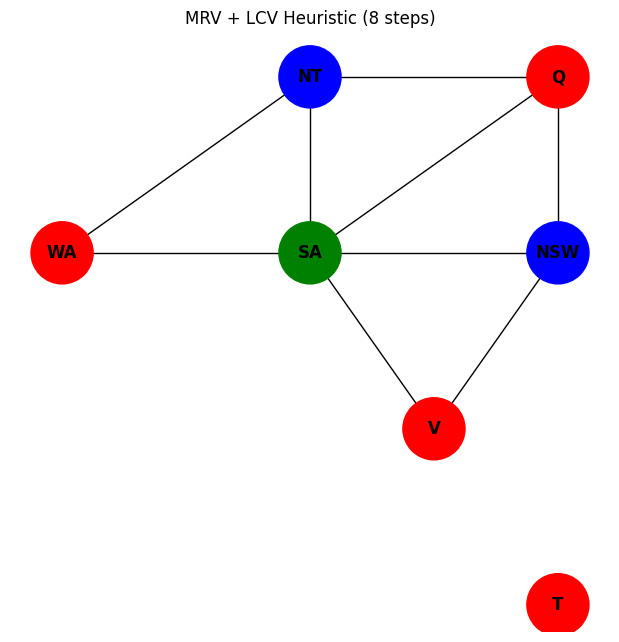

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

variables = ["V", "SA", "NT", "WA", "NSW", "Q", "T"]
colors = ["Red", "Green", "Blue"]

# Adjacency list (neighbors)
neighbors = {
    "WA": ["NT", "SA"],
    "NT": ["WA", "SA", "Q"],
    "SA": ["WA", "NT", "Q", "NSW", "V"],
    "Q": ["NT", "SA", "NSW"],
    "NSW": ["SA", "Q", "V"],
    "V": ["SA", "NSW"],
    "T": []
}

# ---------------- Utility Functions ------------------

# Check if assignment is valid
def is_valid(assignment, var, value):
    for n in neighbors[var]:
        if n in assignment and assignment[n] == value:
            return False
    return True

def visualize_coloring(solution, title):
    G = nx.Graph()

    # Add nodes and edges
    for var in variables:
        G.add_node(var)
    for var, neighs in neighbors.items():
        for n in neighs:
            G.add_edge(var, n)

    # Node positions for Australia-like layout
    pos = {
        "WA": (0, 0),
        "NT": (2, 2),
        "SA": (2, 0),
        "Q": (4, 2),
        "NSW": (4, 0),
        "V": (3, -2),
        "T": (4, -4)
    }

    node_colors = [solution.get(node, "white") for node in G.nodes()]

    plt.figure(figsize=(6, 6))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=2000,
        font_size=12,
        font_weight="bold",
        edge_color="black"
    )
    plt.title(title)
    plt.show()

# ---------------- Backtracking with MRV + LCV ------------------

# Minimum Remaining Values (MRV) heuristic
def select_unassigned_var(assignment):
    unassigned = [v for v in variables if v not in assignment]
    return min(unassigned, key=lambda var: sum(is_valid(assignment, var, c) for c in colors))

# Least Constraining Value (LCV) heuristic
def order_domain_values(var, assignment):
    def conflicts(val):
        return sum(1 for n in neighbors[var] if n not in assignment and not is_valid({**assignment, var: val}, n, val))
    return sorted(colors, key=conflicts)

heuristic_steps = 0
def backtrack_heuristic(assignment):
    global heuristic_steps
    heuristic_steps += 1

    if len(assignment) == len(variables):
        return assignment

    var = select_unassigned_var(assignment)

    for value in order_domain_values(var, assignment):
        if is_valid(assignment, var, value):
            assignment[var] = value
            result = backtrack_heuristic(assignment)
            if result:
                return result
            del assignment[var]  # backtrack

    return None

if __name__ == "__main__":
    # Backtracking with MRV + LCV
    heuristic_solution = backtrack_heuristic({})
    print("Backtracking with MRV + LCV Solution:", heuristic_solution)
    print("Backtracking with MRV + LCV Steps:", heuristic_steps)
    visualize_coloring(heuristic_solution, f"MRV + LCV Heuristic ({heuristic_steps} steps)")


----- Plain Backtracking -----
Plain Backtracking Solution: {'AP': 'Red', 'AR': 'Red', 'AS': 'Green', 'BR': 'Red', 'CG': 'Red', 'GA': 'Red', 'GJ': 'Red', 'HR': 'Red', 'HP': 'Green', 'JH': 'Green', 'KA': 'Green', 'KL': 'Red', 'MP': 'Green', 'MH': 'Blue', 'MN': 'Red', 'ML': 'Red', 'MZ': 'Blue', 'NL': 'Blue', 'OD': 'Blue', 'PB': 'Blue', 'RJ': 'Yellow', 'SK': 'Red', 'TN': 'Blue', 'TS': 'Yellow', 'TR': 'Yellow', 'UP': 'Blue', 'UK': 'Yellow', 'WB': 'Yellow', 'JK': 'Red'}
Plain Backtracking Steps: 30


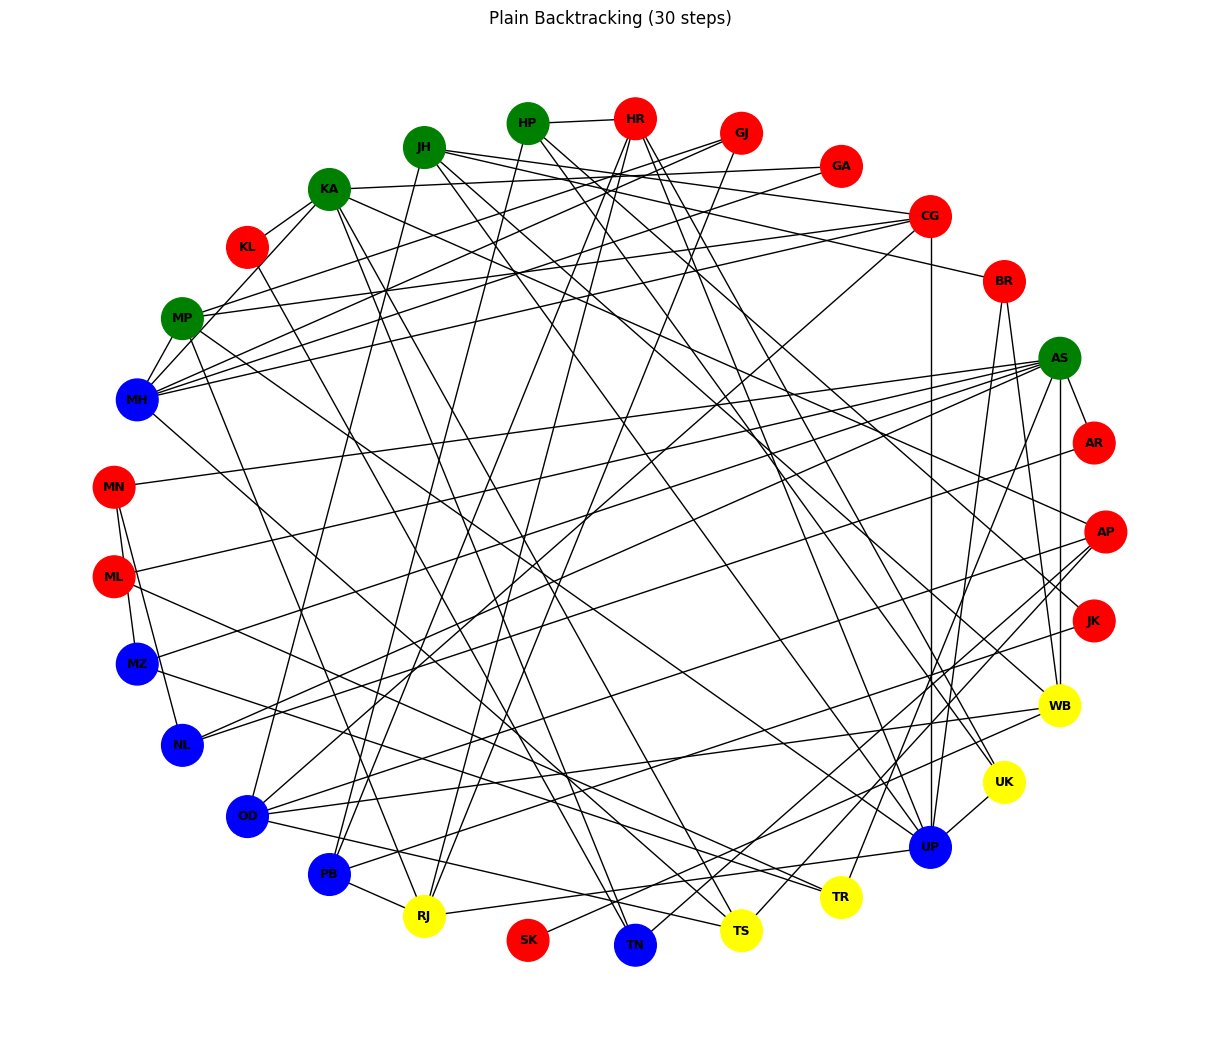


----- MRV + LCV Heuristic -----
MRV+LCV Solution: {'AP': 'Red', 'KA': 'Green', 'TN': 'Blue', 'KL': 'Red', 'TS': 'Blue', 'MH': 'Red', 'GA': 'Blue', 'OD': 'Green', 'CG': 'Blue', 'JH': 'Red', 'MP': 'Green', 'UP': 'Yellow', 'BR': 'Green', 'RJ': 'Red', 'WB': 'Blue', 'AS': 'Red', 'AR': 'Green', 'NL': 'Blue', 'MN': 'Green', 'MZ': 'Blue', 'TR': 'Green', 'ML': 'Blue', 'GJ': 'Green', 'HR': 'Green', 'PB': 'Blue', 'HP': 'Red', 'UK': 'Blue', 'JK': 'Green', 'SK': 'Red'}
Heuristic Steps: 30

MRV/LCV choices per step:
Step 1: MRV chose AP, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 2: MRV chose KA, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 3: MRV chose TN, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 4: MRV chose KL, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 5: MRV chose TS, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 6: MRV chose MH, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 7: MRV chose GA, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 8: MRV chose OD, 

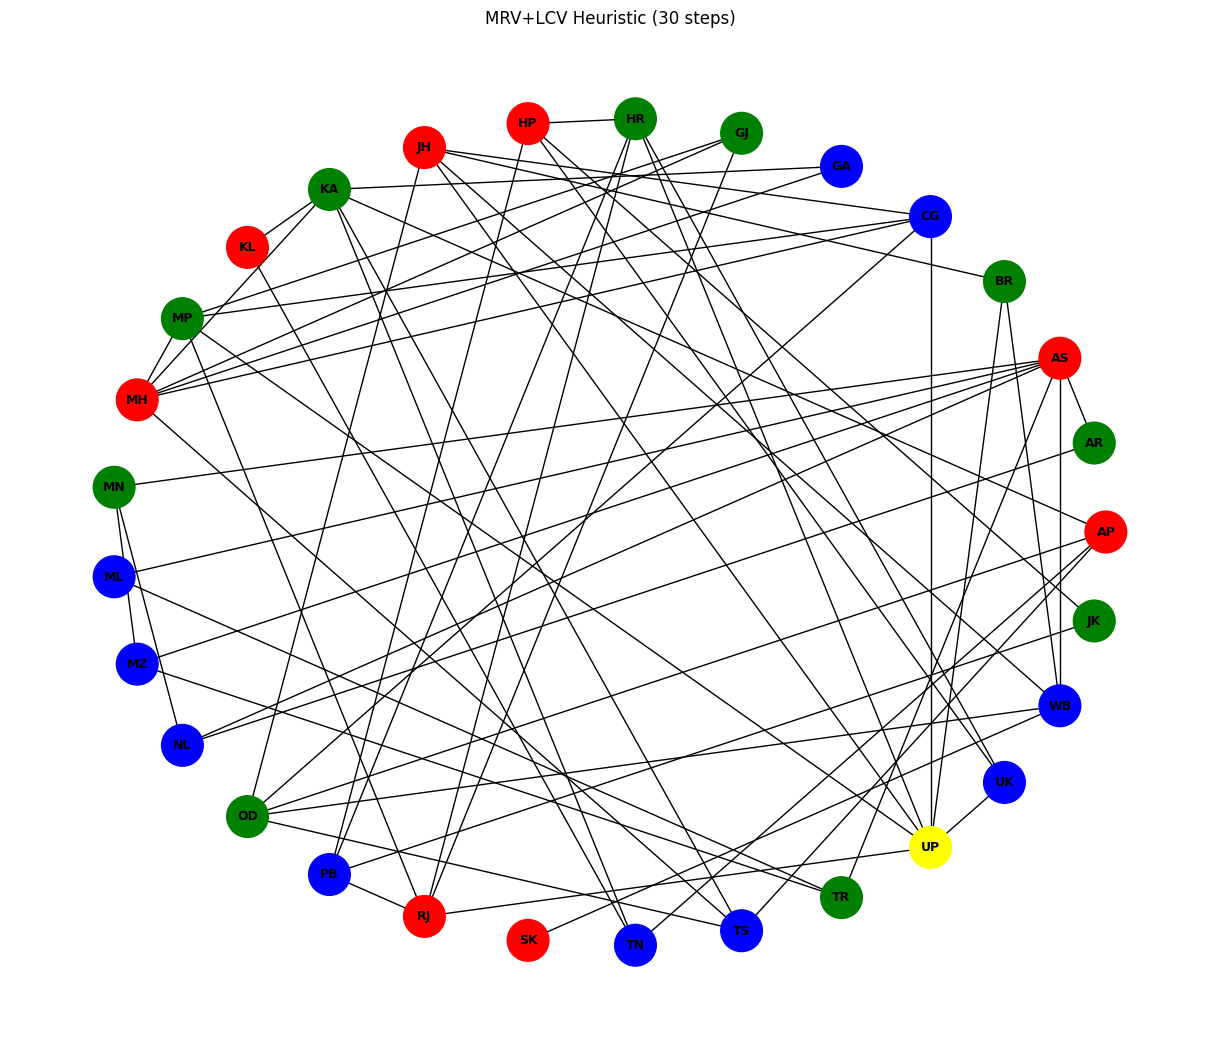


----- MRV + LCV + AC-3 -----
AC-3 Solution: {'AP': 'Red', 'KA': 'Green', 'TN': 'Blue', 'KL': 'Red', 'TS': 'Blue', 'MH': 'Red', 'GA': 'Blue', 'OD': 'Green', 'CG': 'Blue', 'JH': 'Red', 'MP': 'Green', 'UP': 'Yellow', 'BR': 'Green', 'RJ': 'Red', 'HR': 'Green', 'PB': 'Blue', 'HP': 'Yellow', 'UK': 'Red', 'WB': 'Blue', 'JK': 'Red', 'AS': 'Red', 'AR': 'Green', 'NL': 'Blue', 'MN': 'Green', 'MZ': 'Blue', 'TR': 'Green', 'ML': 'Blue', 'GJ': 'Blue', 'SK': 'Red'}
AC-3 Steps: 30

MRV/LCV choices per step (AC-3):
Step 1: MRV chose AP, LCV order ['Red', 'Green', 'Blue', 'Yellow']
Step 2: MRV chose KA, LCV order ['Green', 'Blue', 'Yellow']
Step 3: MRV chose TN, LCV order ['Blue', 'Yellow']
Step 4: MRV chose KL, LCV order ['Red', 'Yellow']
Step 5: MRV chose TS, LCV order ['Blue', 'Yellow']
Step 6: MRV chose MH, LCV order ['Red', 'Yellow']
Step 7: MRV chose GA, LCV order ['Blue', 'Yellow']
Step 8: MRV chose OD, LCV order ['Green', 'Yellow']
Step 9: MRV chose CG, LCV order ['Blue', 'Yellow']
Step 10: MRV 

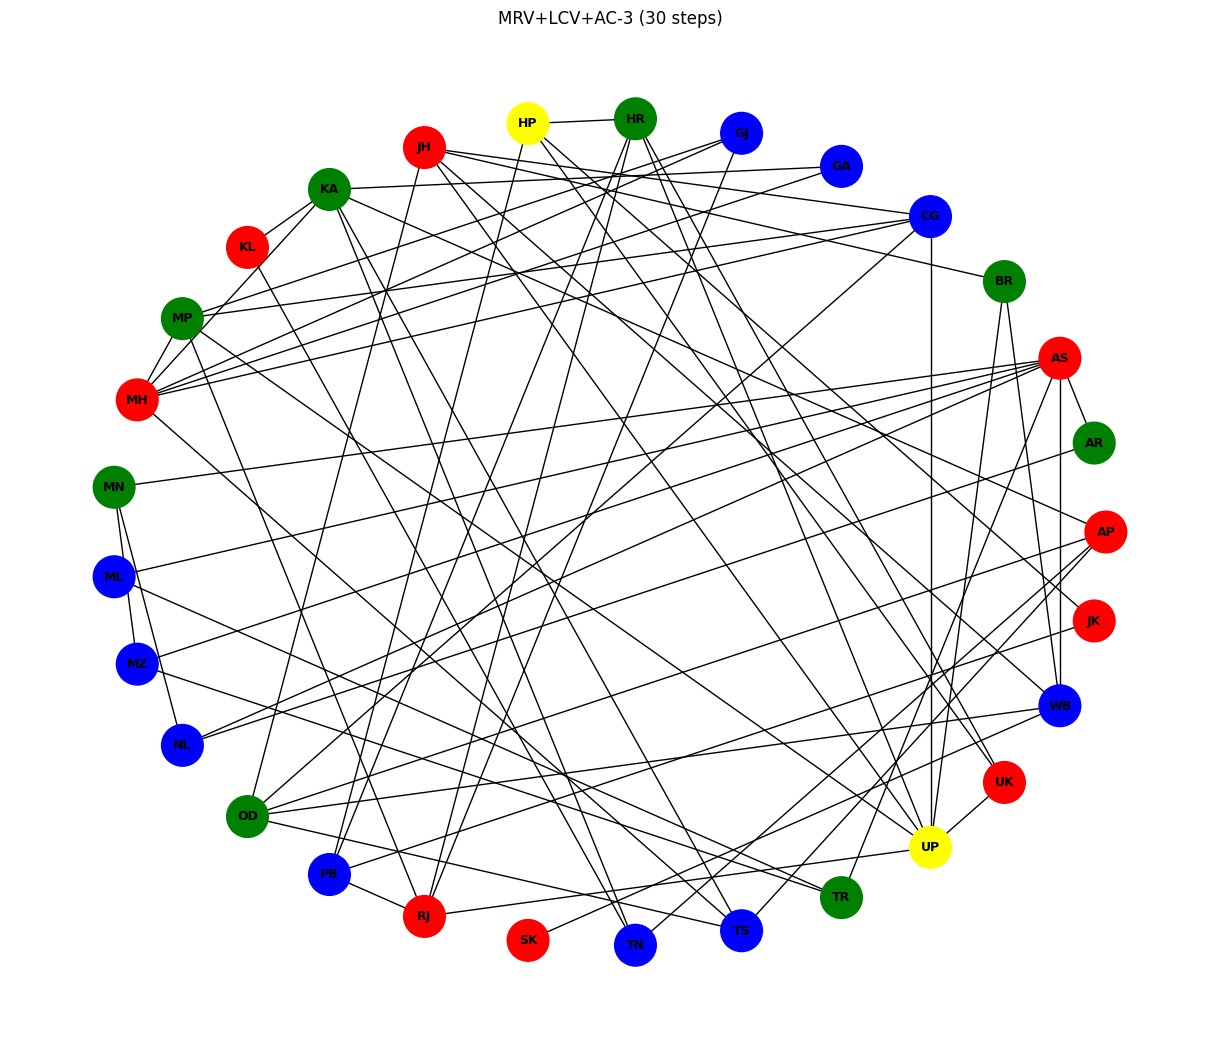


Comparison Table:
| Algorithm                   | Steps Explored |
|-----------------------------|---------------|
| Plain Backtracking          | 30 |
| MRV + LCV Heuristic         | 30 |
| MRV + LCV + AC-3 Heuristic | 30 |


In [4]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# ----- Map data -----
variables = ["AP", "AR", "AS", "BR", "CG", "GA", "GJ", "HR", "HP", "JH", "KA",
             "KL", "MP", "MH", "MN", "ML", "MZ", "NL", "OD", "PB", "RJ", "SK",
             "TN", "TS", "TR", "UP", "UK", "WB", "JK"]

colors = ["Red", "Green", "Blue", "Yellow"]

neighbors = {
    "AP": ["TS", "OD", "TN", "KA"],
    "AR": ["AS", "NL"],
    "AS": ["AR", "NL", "ML", "TR", "MZ", "MN", "WB"],
    "BR": ["UP", "JH", "WB"],
    "CG": ["UP", "JH", "OD", "MH"],
    "GA": ["MH", "KA"],
    "GJ": ["MH", "RJ"],
    "HR": ["PB", "HP", "UK", "RJ"],
    "HP": ["JK", "PB", "HR", "UK"],
    "JH": ["BR", "UP", "CG", "OD", "WB"],
    "KA": ["MH", "AP", "TS", "TN", "KL", "GA"],
    "KL": ["KA", "TN"],
    "MP": ["RJ", "UP", "CG", "MH", "GJ"],
    "MH": ["GJ", "MP", "CG", "TS", "KA", "GA"],
    "MN": ["AS", "MZ", "NL"],
    "ML": ["AS", "TR"],
    "MZ": ["AS", "MN", "TR"],
    "NL": ["AR", "AS", "MN"],
    "OD": ["WB", "JH", "CG", "AP", "TS"],
    "PB": ["JK", "HP", "HR", "RJ"],
    "RJ": ["PB", "HR", "MP", "GJ", "UP"],
    "SK": ["WB"],
    "TN": ["AP", "KA", "KL"],
    "TS": ["MH", "KA", "AP", "OD"],
    "TR": ["AS", "ML", "MZ"],
    "UP": ["UK", "HR", "RJ", "MP", "CG", "JH", "BR"],
    "UK": ["HP", "HR", "UP"],
    "WB": ["BR", "JH", "OD", "AS", "SK"],
    "JK": ["HP", "PB"]
}

# ----- Utility: assignment validity -----
def is_valid(assignment, var, value):
    for n in neighbors[var]:
        if n in assignment and assignment[n] == value:
            return False
    return True

# ----- Plain Backtracking -----
plain_steps = 0
def backtrack_plain(assignment):
    global plain_steps
    plain_steps += 1
    if len(assignment) == len(variables):
        return assignment
    for var in variables:
        if var not in assignment:
            break
    for value in colors:
        if is_valid(assignment, var, value):
            assignment[var] = value
            result = backtrack_plain(assignment)
            if result:
                return result
            del assignment[var]
    return None

# ----- MRV + LCV -----
def select_unassigned_var(assignment):
    unassigned = [v for v in variables if v not in assignment]
    # Count valid colors left for each variable
    return min(unassigned, key=lambda var: sum(is_valid(assignment, var, c) for c in colors))

def order_domain_values(var, assignment):
    def conflicts(val):
        return sum(1 for n in neighbors[var] if n not in assignment and not is_valid({**assignment, var: val}, n, val))
    return sorted(colors, key=conflicts)

heuristic_steps = 0
mrv_lcv_log = []
def backtrack_heuristic(assignment):
    global heuristic_steps, mrv_lcv_log
    heuristic_steps += 1
    if len(assignment) == len(variables):
        return assignment
    var = select_unassigned_var(assignment)
    lcv_order = order_domain_values(var, assignment)
    mrv_lcv_log.append(f"Step {heuristic_steps}: MRV chose {var}, LCV order {lcv_order}")
    for value in lcv_order:
        if is_valid(assignment, var, value):
            assignment[var] = value
            result = backtrack_heuristic(assignment)
            if result:
                return result
            del assignment[var]
    return None

# ----- AC-3 -----
def ac3(domains):
    queue = deque()
    for var in variables:
        for neighbor in neighbors[var]:
            queue.append((var, neighbor))
    while queue:
        xi, xj = queue.popleft()
        if revise(domains, xi, xj):
            if not domains[xi]:
                return False
            for xk in neighbors[xi]:
                if xk != xj:
                    queue.append((xk, xi))
    return True

def revise(domains, xi, xj):
    revised = False
    for x in set(domains[xi]):
        if all(x == y for y in domains[xj]):
            domains[xi].remove(x)
            revised = True
    return revised

ac3_steps = 0
ac3_log = []
def backtrack_ac3(assignment, domains):
    global ac3_steps, ac3_log
    ac3_steps += 1
    if len(assignment) == len(variables):
        return assignment
    # MRV selection based on domain size
    unassigned = [v for v in variables if v not in assignment]
    var = min(unassigned, key=lambda v: len(domains[v]))
    lcv_order = sorted(domains[var], key=lambda val:
        sum(1 for n in neighbors[var] if val in domains[n]))
    ac3_log.append(f"Step {ac3_steps}: MRV chose {var}, LCV order {lcv_order}")
    for value in lcv_order:
        assignment[var] = value
        local_domains = {v: list(domains[v]) for v in domains}
        local_domains[var] = [value]
        if ac3(local_domains):
            result = backtrack_ac3(assignment, local_domains)
            if result:
                return result
        del assignment[var]
    return None

# ----- Visualization -----
def visualize_coloring(solution, title):
    G = nx.Graph()
    for var in variables:
        G.add_node(var)
    for var, neighs in neighbors.items():
        for n in neighs:
            G.add_edge(var, n)
    # Use circular layout for India states
    pos = nx.circular_layout(G)
    node_colors = [solution.get(node, "white") for node in G.nodes()]
    plt.figure(figsize=(12,10))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=900,
            font_size=9, font_weight="bold", edge_color="black")
    plt.title(title)
    plt.show()

# ----- Run/Compare -----
if __name__ == "__main__":
    print("----- Plain Backtracking -----")
    plain_solution = backtrack_plain({})
    print("Plain Backtracking Solution:", plain_solution)
    print("Plain Backtracking Steps:", plain_steps)
    visualize_coloring(plain_solution, f"Plain Backtracking ({plain_steps} steps)")
    print("\n----- MRV + LCV Heuristic -----")
    heuristic_solution = backtrack_heuristic({})
    print("MRV+LCV Solution:", heuristic_solution)
    print("Heuristic Steps:", heuristic_steps)
    print("\nMRV/LCV choices per step:")
    for log in mrv_lcv_log:
        print(log)
    visualize_coloring(heuristic_solution, f"MRV+LCV Heuristic ({heuristic_steps} steps)")
    print("\n----- MRV + LCV + AC-3 -----")
    domains = {v: list(colors) for v in variables}
    ac3_solution = backtrack_ac3({}, domains)
    print("AC-3 Solution:", ac3_solution)
    print("AC-3 Steps:", ac3_steps)
    print("\nMRV/LCV choices per step (AC-3):")
    for log in ac3_log:
        print(log)
    visualize_coloring(ac3_solution, f"MRV+LCV+AC-3 ({ac3_steps} steps)")
    # Output comparison table
    print("\nComparison Table:")
    print("| Algorithm                   | Steps Explored |")
    print("|-----------------------------|---------------|")
    print(f"| Plain Backtracking          | {plain_steps} |")
    print(f"| MRV + LCV Heuristic         | {heuristic_steps} |")
    print(f"| MRV + LCV + AC-3 Heuristic | {ac3_steps} |")
